# 02 — Análise Exploratória (EDA)
Entendimento visual e estatístico de todas as séries antes da modelagem.  
Cada seção responde uma pergunta específica sobre os dados.


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

BASE_DIR   = Path().resolve().parent
RAW_DIR    = BASE_DIR / 'data' / 'raw'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

# Paleta consistente
CORES = {
    'pld':     '#E63946',
    'ear':     '#2A9D8F',
    'ena':     '#457B9D',
    'termica': '#E9C46A',
    'precip':  '#6A994E',
}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': True,
                     'grid.alpha': 0.35, 'axes.spines.top': False,
                     'axes.spines.right': False})
print("Imports OK")


Imports OK


## 1. Carga e Merge dos Dados

In [2]:
# ── Carregar todos os parquets ────────────────────────────────────────────
df_pld    = pd.read_parquet(RAW_DIR / 'pld_mensal_raw.parquet')
df_ear    = pd.read_parquet(RAW_DIR / 'ear_mensal_raw.parquet')
df_ena    = pd.read_parquet(RAW_DIR / 'ena_mensal_raw.parquet')
df_term   = pd.read_parquet(RAW_DIR / 'termica_mensal_raw.parquet')
df_precip = pd.read_parquet(RAW_DIR / 'precipitacao_mensal_raw.parquet')

# Merge na data de referência
df = (df_pld[['din_referencia','val_pld']]
      .merge(df_ear,    on='din_referencia', how='left')
      .merge(df_ena,    on='din_referencia', how='left')
      .merge(df_term,   on='din_referencia', how='left')
      .merge(df_precip, on='din_referencia', how='left')
      .sort_values('din_referencia')
      .reset_index(drop=True))

df['ano'] = df['din_referencia'].dt.year
df['mes'] = df['din_referencia'].dt.month

print(f"Shape: {df.shape}")
print(f"Período: {df['din_referencia'].min().strftime('%b/%Y')} → {df['din_referencia'].max().strftime('%b/%Y')}")
print(f"\nNulls:\n{df.isna().sum()}")
df.head(3)


Shape: (120, 8)
Período: Jan/2015 → Dec/2024

Nulls:
din_referencia           0
val_pld                  0
ear_pct_se               0
ena_mwmed_se             0
geracao_termica_mwmed    0
precipitacao_mm          0
ano                      0
mes                      0
dtype: int64


,din_referencia,val_pld,ear_pct_se,ena_mwmed_se,geracao_termica_mwmed,precipitacao_mm,ano,mes
0,2015-01-01,148.94,76.96,33813.0,5915.0,197.6,2015,1
1,2015-02-01,146.93,65.89,36713.0,7061.0,202.7,2015,2
2,2015-03-01,179.73,70.71,37057.0,6663.0,184.6,2015,3


## 2. Estatísticas Descritivas

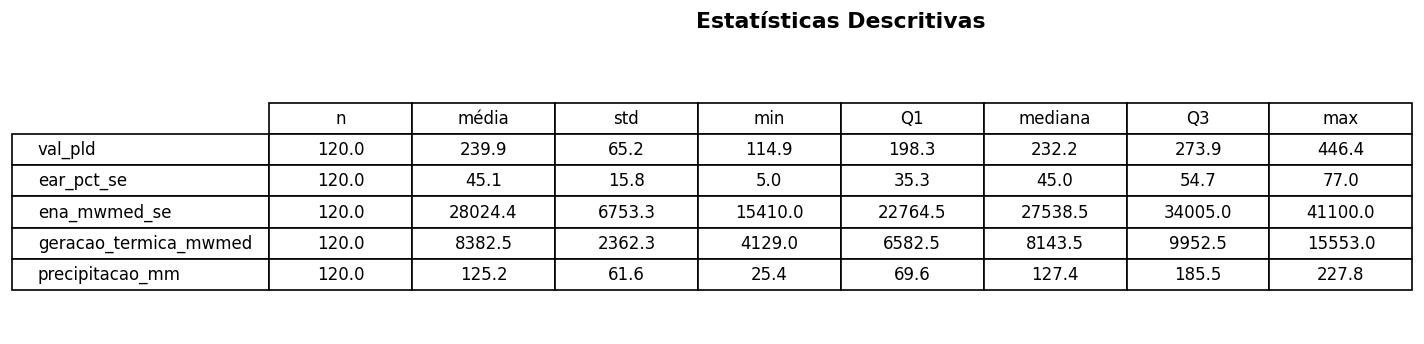

,n,média,std,min,Q1,mediana,Q3,max
val_pld,120.0,239.9,65.2,114.9,198.3,232.2,273.9,446.4
ear_pct_se,120.0,45.1,15.8,5.0,35.3,45.0,54.7,77.0
ena_mwmed_se,120.0,28024.4,6753.3,15410.0,22764.5,27538.5,34005.0,41100.0
geracao_termica_mwmed,120.0,8382.5,2362.3,4129.0,6582.5,8143.5,9952.5,15553.0
precipitacao_mm,120.0,125.2,61.6,25.4,69.6,127.4,185.5,227.8


In [3]:
stats = df[['val_pld','ear_pct_se','ena_mwmed_se','geracao_termica_mwmed','precipitacao_mm']].describe().T
stats.columns = ['n','média','std','min','Q1','mediana','Q3','max']
stats = stats.round(1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tbl = ax.table(cellText=stats.values, colLabels=stats.columns,
               rowLabels=stats.index, cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
plt.title('Estatísticas Descritivas', pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_00_estatisticas.png', bbox_inches='tight')
plt.show()
stats


## 3. Série Temporal do PLD

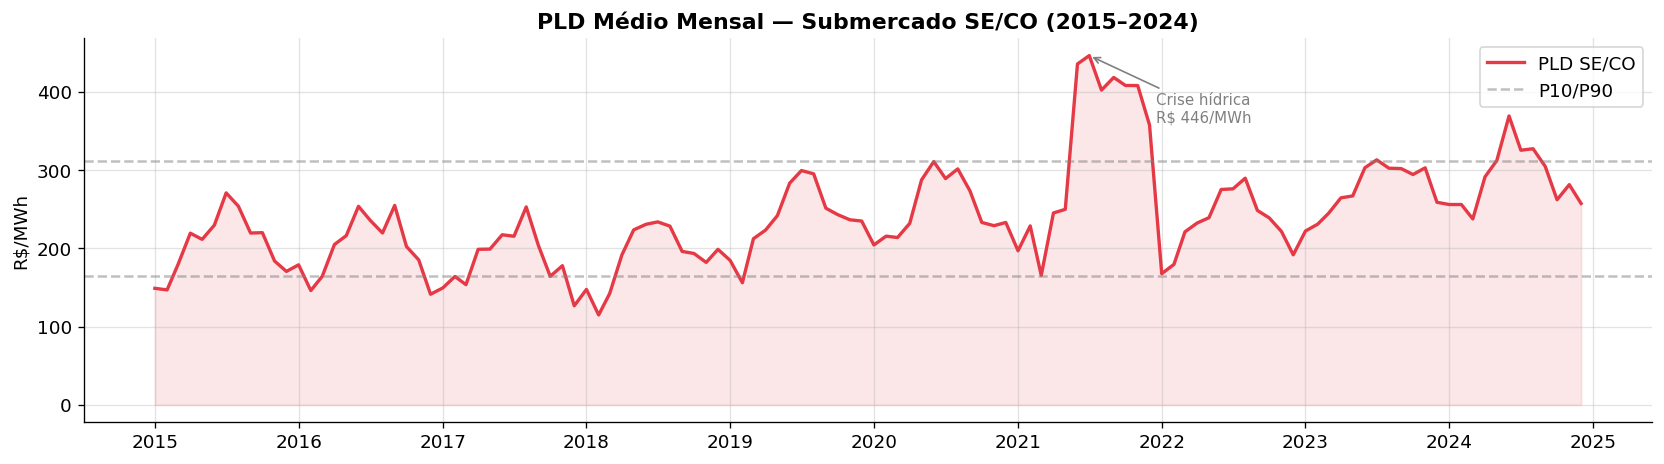

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['din_referencia'], df['val_pld'], color=CORES['pld'], lw=2, label='PLD SE/CO')
ax.fill_between(df['din_referencia'], df['val_pld'], alpha=0.12, color=CORES['pld'])

# Anotação crise 2021
pico = df.loc[df['val_pld'].idxmax()]
ax.annotate(f"Crise hídrica\nR$ {pico['val_pld']:.0f}/MWh",
            xy=(pico['din_referencia'], pico['val_pld']),
            xytext=(40, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

# Limites mínimo/máximo histórico
ax.axhline(df['val_pld'].quantile(0.1), ls='--', color='gray', alpha=0.5, label='P10/P90')
ax.axhline(df['val_pld'].quantile(0.9), ls='--', color='gray', alpha=0.5)

ax.set_title('PLD Médio Mensal — Submercado SE/CO (2015–2024)', fontweight='bold')
ax.set_ylabel('R$/MWh')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_01_serie_pld.png', bbox_inches='tight')
plt.show()


## 4. Todas as Séries — Visão Conjunta

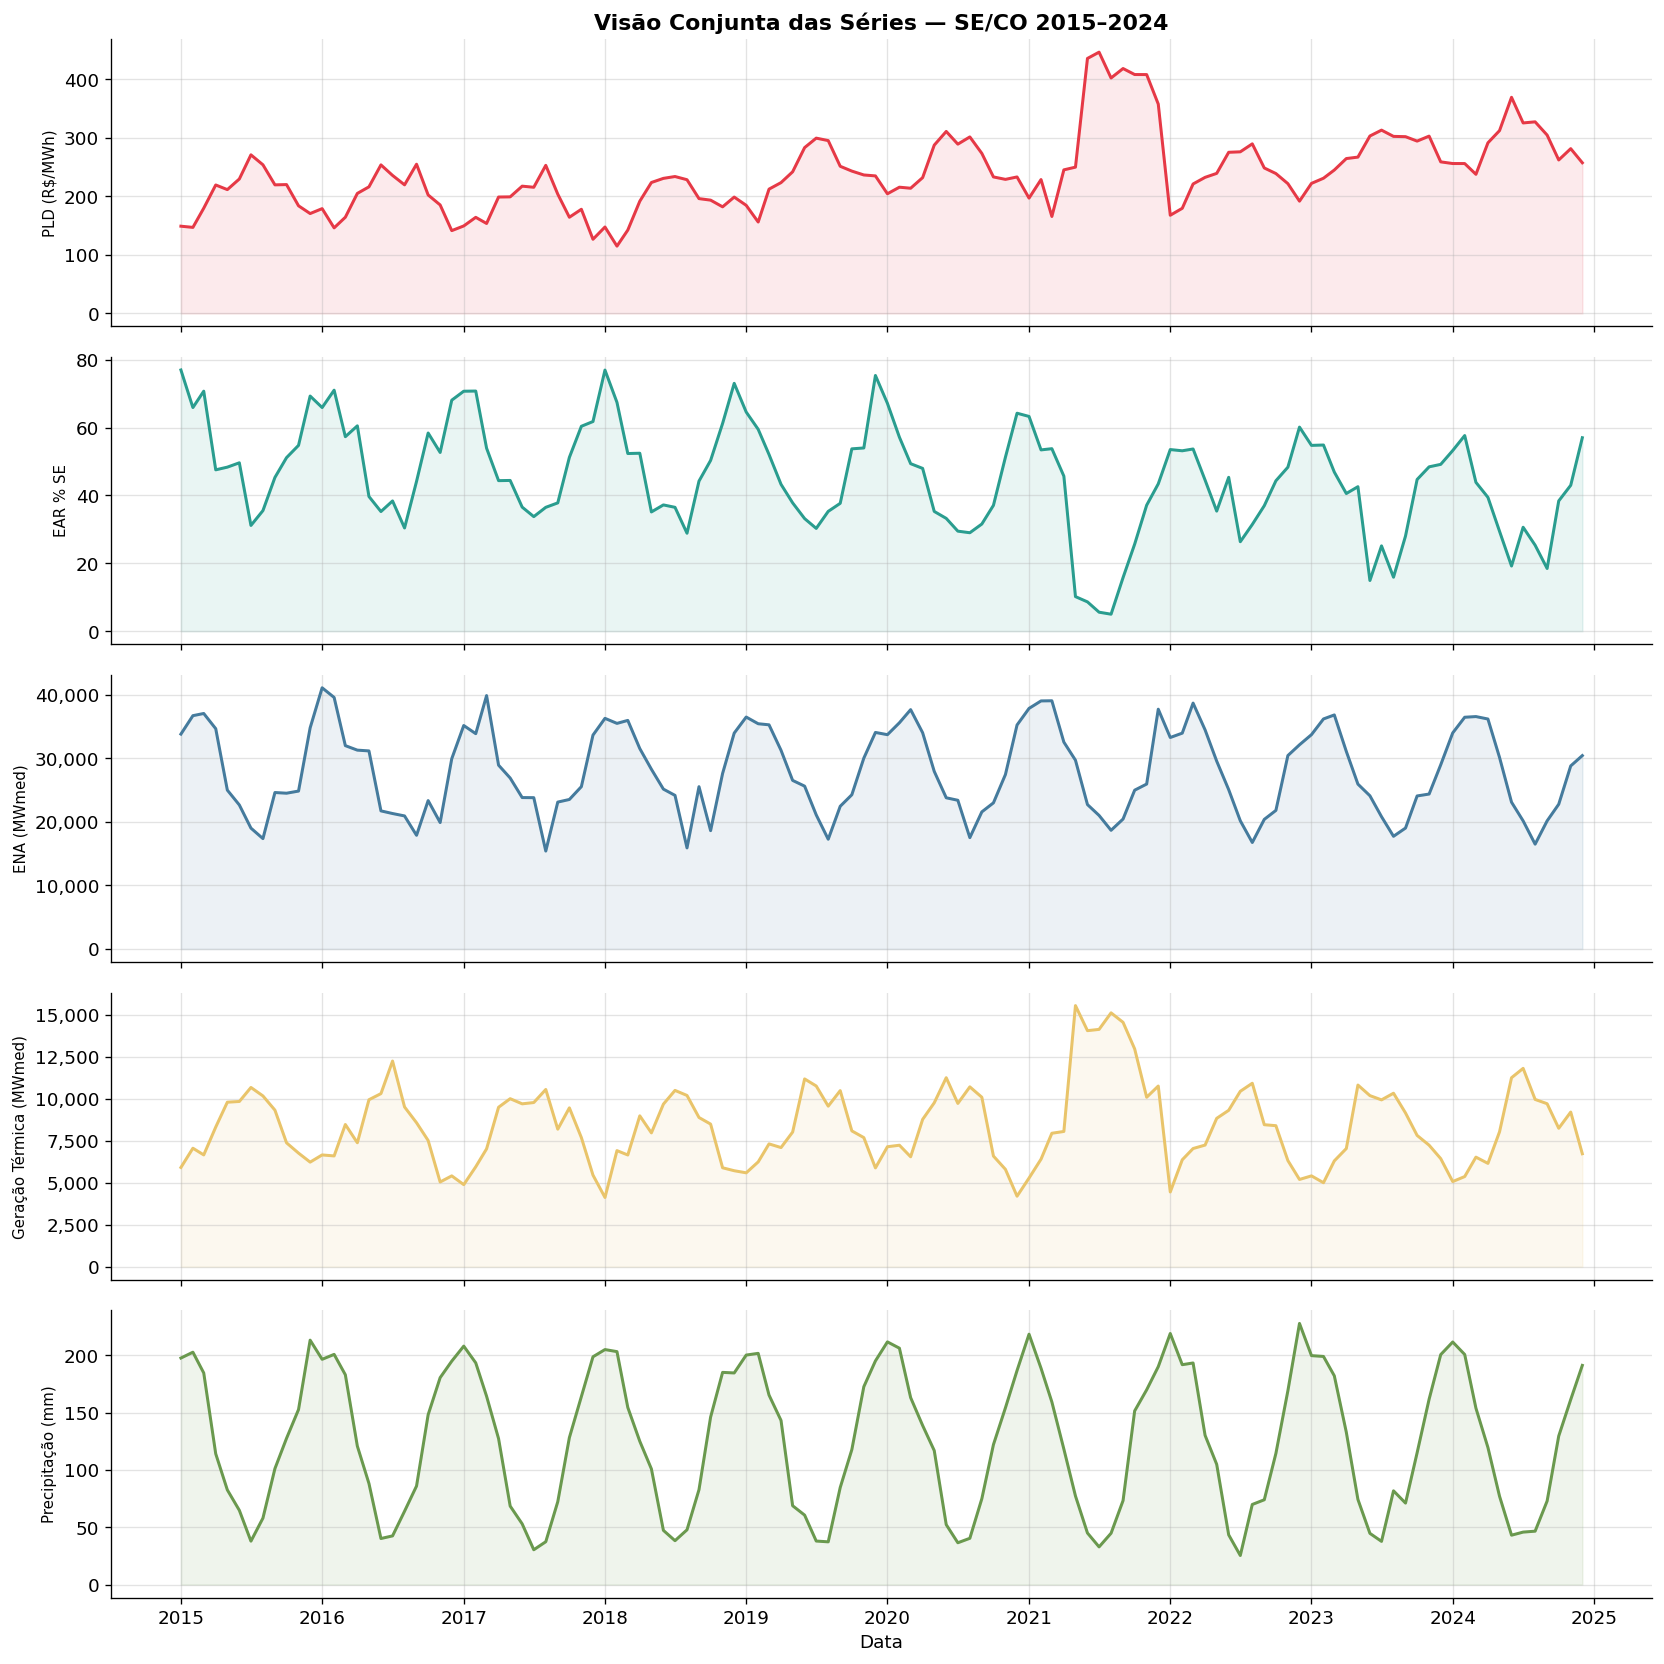

In [5]:
series = [
    ('val_pld',                  'PLD (R$/MWh)',        CORES['pld']),
    ('ear_pct_se',               'EAR % SE',            CORES['ear']),
    ('ena_mwmed_se',             'ENA (MWmed)',          CORES['ena']),
    ('geracao_termica_mwmed',    'Geração Térmica (MWmed)', CORES['termica']),
    ('precipitacao_mm',          'Precipitação (mm)',   CORES['precip']),
]

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)
for ax, (col, label, cor) in zip(axes, series):
    ax.plot(df['din_referencia'], df[col], color=cor, lw=1.8)
    ax.fill_between(df['din_referencia'], df[col], alpha=0.1, color=cor)
    ax.set_ylabel(label, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[0].set_title('Visão Conjunta das Séries — SE/CO 2015–2024', fontweight='bold')
axes[-1].set_xlabel('Data')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_02_series_conjuntas.png', bbox_inches='tight')
plt.show()


## 5. Sazonalidade Mensal do PLD

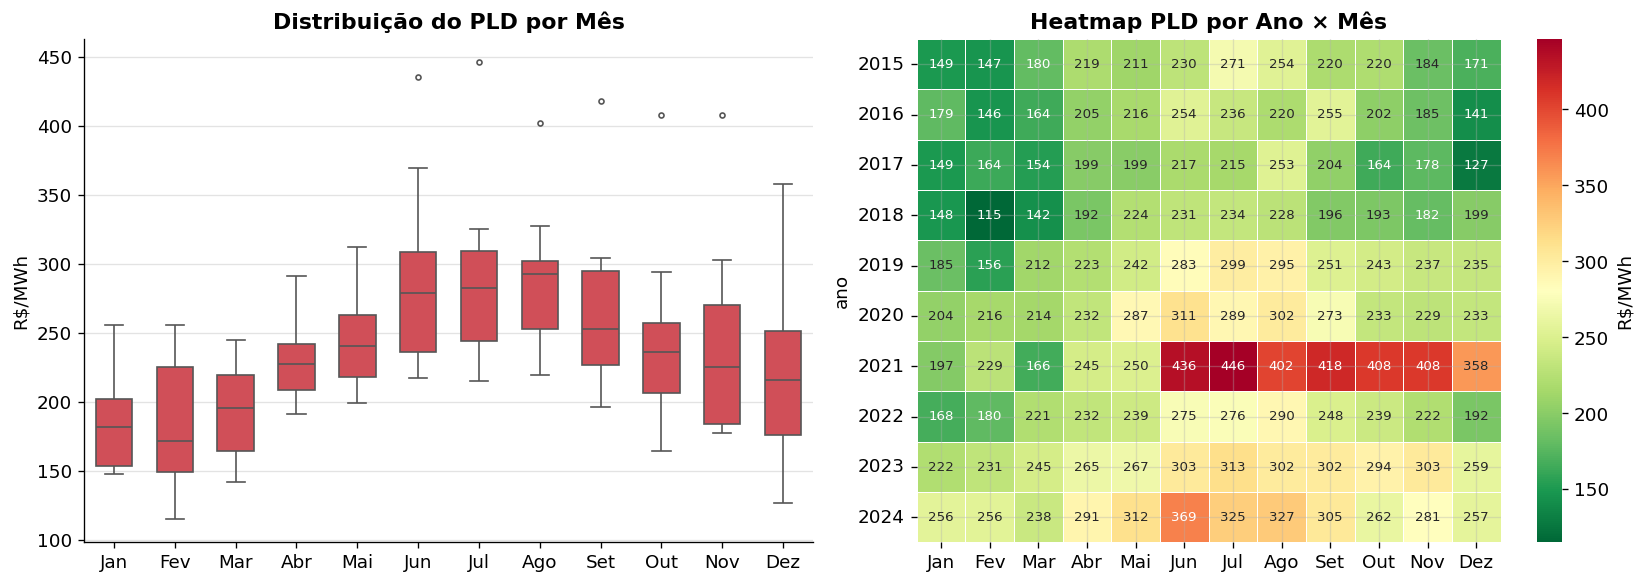

In [6]:
meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por mês
df_saz = df.copy()
df_saz['mes_nome'] = df_saz['mes'].map(dict(enumerate(meses_label, 1)))
df_saz['mes_nome'] = pd.Categorical(df_saz['mes_nome'], categories=meses_label, ordered=True)

sns.boxplot(data=df_saz, x='mes_nome', y='val_pld', ax=ax1,
            color=CORES['pld'], width=0.6, fliersize=3)
ax1.set_title('Distribuição do PLD por Mês', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('R$/MWh')

# Média mensal por ano (heatmap)
pivot = df.pivot_table(values='val_pld', index='ano', columns='mes', aggfunc='mean')
pivot.columns = meses_label
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn_r', fmt='.0f', annot=True,
            linewidths=0.4, cbar_kws={'label': 'R$/MWh'}, annot_kws={'size': 8})
ax2.set_title('Heatmap PLD por Ano × Mês', fontweight='bold')
ax2.set_xlabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_03_sazonalidade.png', bbox_inches='tight')
plt.show()


## 6. Correlações entre Variáveis

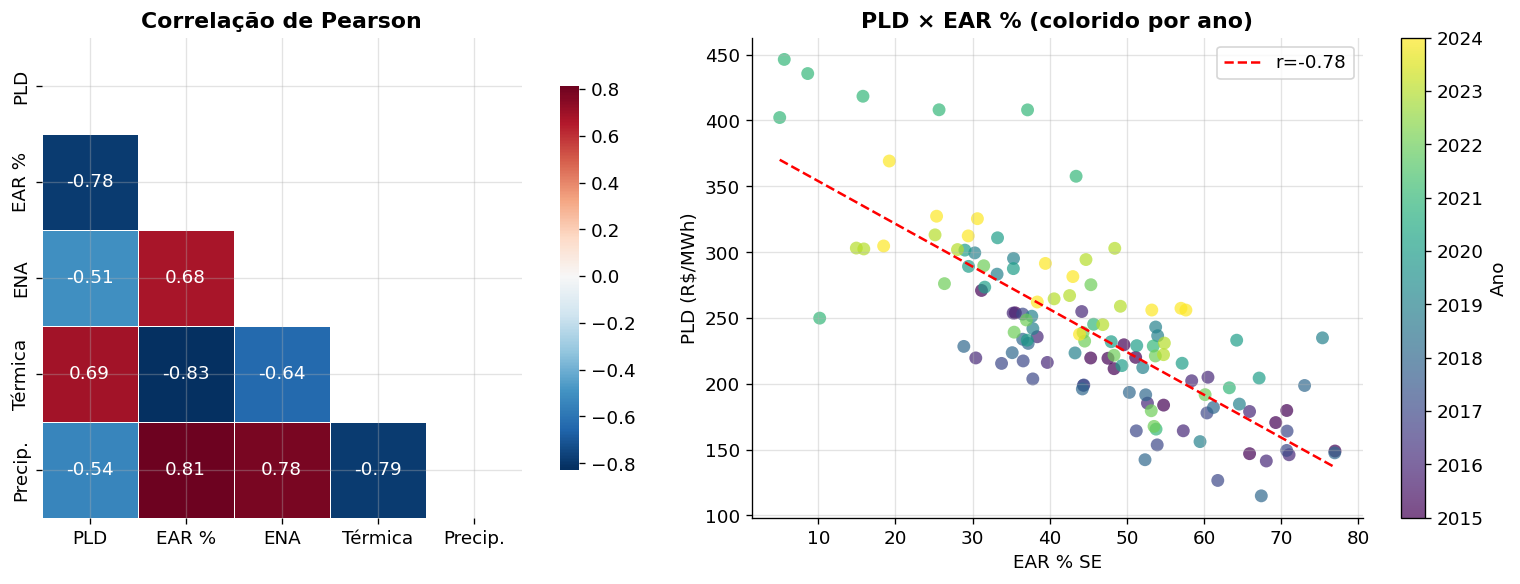

Correlações com PLD:
EAR %     -0.784316
Precip.   -0.544265
ENA       -0.505793
Térmica    0.687713
PLD        1.000000
Name: PLD, dtype: float64


In [7]:
colunas = ['val_pld','ear_pct_se','ena_mwmed_se','geracao_termica_mwmed','precipitacao_mm']
labels  = ['PLD','EAR %','ENA','Térmica','Precip.']

corr = df[colunas].corr()
corr.index = labels
corr.columns = labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax1.set_title('Correlação de Pearson', fontweight='bold')

# Scatter PLD vs EAR (relação mais forte esperada)
sc = ax2.scatter(df['ear_pct_se'], df['val_pld'],
                 c=df['ano'], cmap='viridis', alpha=0.7, s=60, edgecolors='none')
plt.colorbar(sc, ax=ax2, label='Ano')
ax2.set_xlabel('EAR % SE')
ax2.set_ylabel('PLD (R$/MWh)')
ax2.set_title('PLD × EAR % (colorido por ano)', fontweight='bold')

# Linha de tendência
m, b = np.polyfit(df['ear_pct_se'], df['val_pld'], 1)
x_line = np.linspace(df['ear_pct_se'].min(), df['ear_pct_se'].max(), 100)
ax2.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'r={corr.loc["PLD","EAR %"]:.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_04_correlacoes.png', bbox_inches='tight')
plt.show()
print(f"Correlações com PLD:\n{corr['PLD'].sort_values()}")


## 7. Teste de Estacionariedade (ADF)

In [8]:
print("Teste Augmented Dickey-Fuller (H0: série tem raiz unitária = não estacionária)")
print("=" * 65)
for col, label in zip(['val_pld','ear_pct_se','ena_mwmed_se','geracao_termica_mwmed'],
                      ['PLD','EAR %','ENA','Térmica']):
    stat, p, _, _, crit, _ = adfuller(df[col].dropna(), autolag='AIC')
    status = "✅ Estacionária" if p < 0.05 else "⚠️  Não estacionária"
    print(f"{label:<12} | p-valor={p:.4f} | {status}")


Teste Augmented Dickey-Fuller (H0: série tem raiz unitária = não estacionária)
PLD          | p-valor=0.5627 | ⚠️  Não estacionária
EAR %        | p-valor=0.4893 | ⚠️  Não estacionária
ENA          | p-valor=0.1253 | ⚠️  Não estacionária
Térmica      | p-valor=0.0967 | ⚠️  Não estacionária


## 8. ACF / PACF do PLD

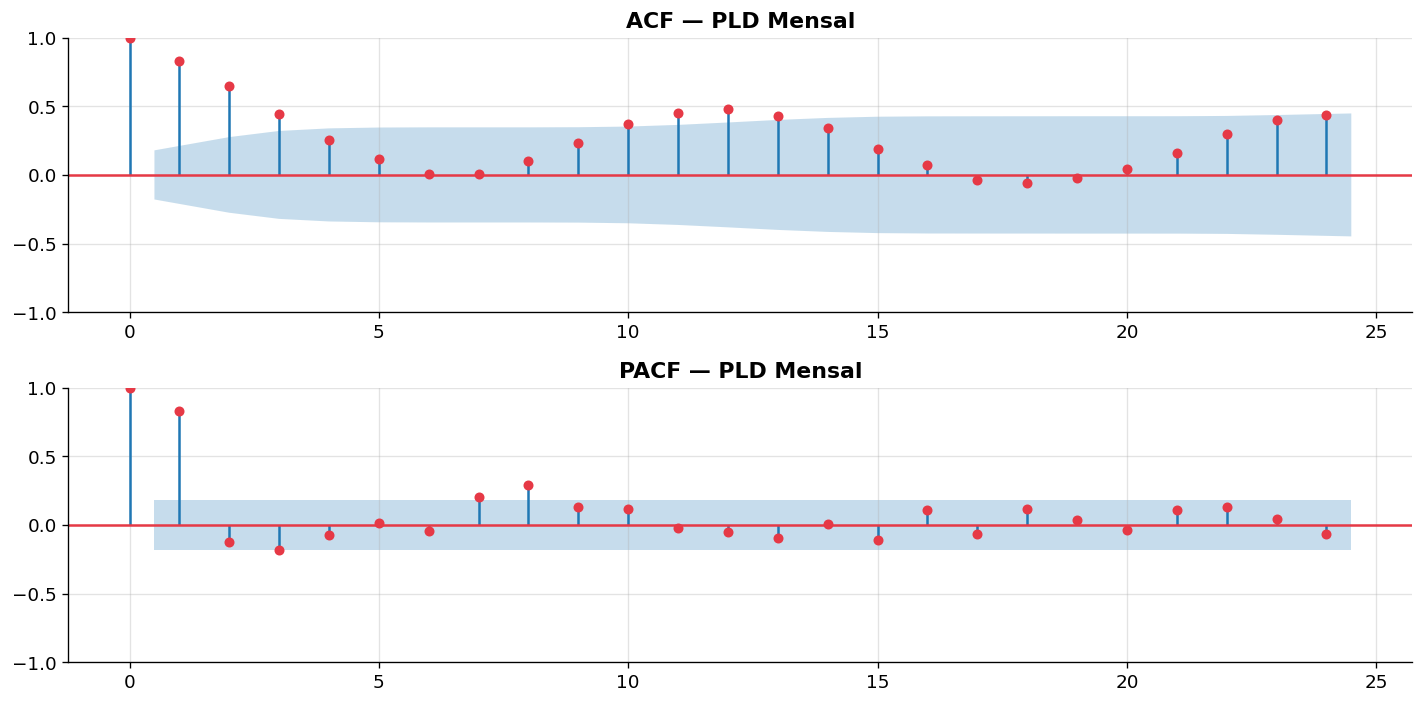


📌 Insights EDA salvos em outputs/


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(df['val_pld'].dropna(),  lags=24, ax=axes[0], color=CORES['pld'])
axes[0].set_title('ACF — PLD Mensal', fontweight='bold')
plot_pacf(df['val_pld'].dropna(), lags=24, ax=axes[1], color=CORES['pld'], method='ywm')
axes[1].set_title('PACF — PLD Mensal', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_05_acf_pacf.png', bbox_inches='tight')
plt.show()
print("\n📌 Insights EDA salvos em outputs/")
